# Traps and Treasures — Board Analysis

Prototype notebook for exploring board structure and interesting field-set definitions.

**Terminology used throughout:**
- **coordinate** `(c, r)` — column and row *position* (0-indexed integers)
- **labels** of a field — the tuple `(col_label, row_label)` assigned to its column and row

---
## Section 1 — Board Setup

In [18]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from itertools import combinations
from collections import defaultdict

# ── Board parameter (change here to resize everything) ────────────────────────
BOARD_SIZE = 7

In [ ]:
def generate_coordinate_labels(size):
    """
    Generate distinct random integers from 0 to 25 for row and column labels.
    Draws 2*size values without replacement and splits them into
    row labels (first half) and column labels (second half).

    Parameters
    ----------
    size : int
        Board side length.  Requires size * 2 <= 26.

    Returns
    -------
    row_labels : list[int]  — one label per row    (r = 0 … size-1)
    col_labels : list[int]  — one label per column (c = 0 … size-1)
    """
    pool = random.sample(range(2, 26), size * 2)
    return pool[:size], pool[size:]

In [20]:
# ── Generate labels (re-run cell to get a fresh random board) ─────────────────
row_labels, col_labels = generate_coordinate_labels(BOARD_SIZE)

# Alternatively, pin specific labels:
# row_labels = [3,  7, 12,  1, 18, 25,  9]
# col_labels = [4, 11,  6, 22,  0, 15, 20]

print(f"Row labels  (r = 0 … {BOARD_SIZE-1}): {row_labels}")
print(f"Col labels  (c = 0 … {BOARD_SIZE-1}): {col_labels}")

Row labels  (r = 0 … 6): [3, 6, 20, 18, 12, 9, 10]
Col labels  (c = 0 … 6): [7, 16, 5, 21, 17, 15, 14]


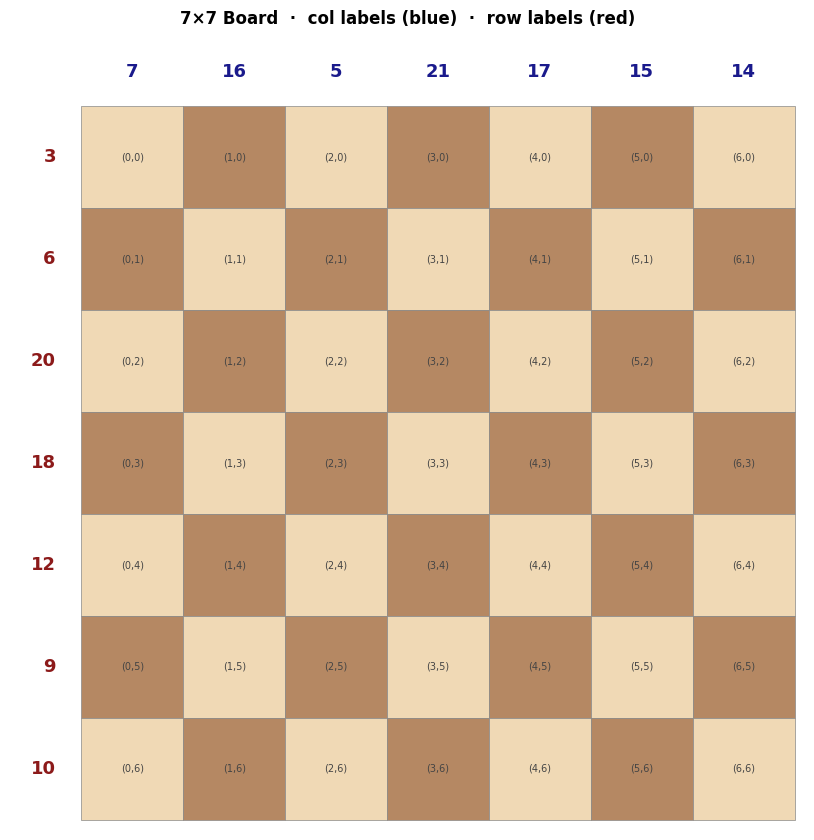

In [21]:
def visualize_board(size, col_labels, row_labels, highlight=None, title="Board"):
    """
    Draw a chess-like board with row / column labels.

    Layout
    ------
    - r = 0 is the top row, r = size-1 is the bottom row.
    - c = 0 is the leftmost column.
    - Column labels (blue) are shown above the board.
    - Row labels (red) are shown to the left of the board.
    - Each cell shows its coordinate (c, r) in small grey text.

    Parameters
    ----------
    highlight : set of (c, r) tuples to colour green, optional
    """
    hl = set(highlight) if highlight else set()
    fig, ax = plt.subplots(figsize=(size + 1.5, size + 1.5))

    for r in range(size):
        svg_y = size - 1 - r            # flip so r=0 appears at the top
        for c in range(size):
            light  = (c + r) % 2 == 0
            base   = '#F0D9B5' if light else '#B58863'
            color  = '#6abf69' if (c, r) in hl else base
            ax.add_patch(patches.Rectangle(
                (c, svg_y), 1, 1,
                linewidth=0.5, edgecolor='#888888', facecolor=color
            ))
            ax.text(c + 0.5, svg_y + 0.5, f'({c},{r})',
                    ha='center', va='center',
                    fontsize=max(5, 9 - size // 3), color='#444444')

    # Column labels — above the board
    for c in range(size):
        ax.text(c + 0.5, size + 0.25, str(col_labels[c]),
                ha='center', va='bottom',
                fontsize=13, fontweight='bold', color='#1a1a8c')

    # Row labels — left of the board
    for r in range(size):
        ax.text(-0.25, size - 1 - r + 0.5, str(row_labels[r]),
                ha='right', va='center',
                fontsize=13, fontweight='bold', color='#8c1a1a')

    ax.set_xlim(-0.7, size + 0.1)
    ax.set_ylim(-0.1, size + 0.7)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    plt.tight_layout()
    plt.show()


visualize_board(
    BOARD_SIZE, col_labels, row_labels,
    title=f"{BOARD_SIZE}×{BOARD_SIZE} Board  ·  col labels (blue)  ·  row labels (red)"
)

---
## Section 2 — Field-Set Functions

Each function returns a **set of `(c, r)` coordinate tuples** — the fields satisfying its condition.

| Function | Condition |
|---|---|
| `get_inbetween_fields` | Fields lying strictly between two fields that share the same sum or product of their *labels* |
| `get_center_fields` | The middle field(s) in terms of label value ordering (median row label × median col label) |
| `get_label_plus_coord_fields` | Fields where one axis's label plus its coordinate position equals the other axis's label |
| `get_sum_min_fields` | Fields whose label-sum (col label + row label) is smaller or larger than all orthogonal neighbors |

In [22]:
def get_inbetween_fields(size, col_labels, row_labels, mode='sum'):
    """
    Fields lying *strictly between* two fields that share the same
    sum (mode='sum') or product (mode='product') of their labels
    (col_labels[c] + row_labels[r]  or  col_labels[c] * row_labels[r]).

    'Between' is defined in the chess sense: field B is between A and C when
    A, B, C are collinear (same row, same column, or same diagonal) and B sits
    strictly inside the segment A–C.

    Notes
    -----
    - The two endpoint fields themselves are *not* included in the result.
    - Pairs that are not collinear contribute no intermediate fields.
    """
    def label_value(c, r):
        return (col_labels[c] + row_labels[r]) if mode == 'sum' else (col_labels[c] * row_labels[r])

    # Group field coordinates by their label sum / product
    groups = defaultdict(list)
    for r in range(size):
        for c in range(size):
            groups[label_value(c, r)].append((c, r))

    between = set()
    for fields in groups.values():
        if len(fields) < 2:
            continue
        for (c1, r1), (c2, r2) in combinations(fields, 2):
            dc, dr = c2 - c1, r2 - r1
            # Determine unit step if the pair is collinear
            if dc == 0 and dr != 0:               # same column
                sc, sr = 0, (1 if dr > 0 else -1)
            elif dr == 0 and dc != 0:             # same row
                sc, sr = (1 if dc > 0 else -1), 0
            elif abs(dc) == abs(dr):              # diagonal
                sc = 1 if dc > 0 else -1
                sr = 1 if dr > 0 else -1
            else:
                continue  # not collinear — no 'between' fields

            # Walk strictly between the two endpoints
            c, r = c1 + sc, r1 + sr
            while (c, r) != (c2, r2):
                between.add((c, r))
                c += sc
                r += sr

    return between

In [23]:
def get_center_fields(size, col_labels, row_labels):
    """
    The middle field(s) in terms of label value ordering.

    For each axis the labels are sorted and the median value(s) identified.
    Returns all fields at the intersection of a median-row and a median-column.

    Odd  size → 1 median per axis → 1 center field
    Even size → 2 medians per axis → up to 4 center fields
    """
    def median_indices(labels):
        """Indices of the median label value(s) in the original list."""
        n = len(labels)
        sorted_vals = sorted(labels)
        if n % 2 == 1:
            med = sorted_vals[n // 2]
            return [i for i, v in enumerate(labels) if v == med]
        else:
            lo, hi = sorted_vals[n // 2 - 1], sorted_vals[n // 2]
            return [i for i, v in enumerate(labels) if v in (lo, hi)]

    row_idxs = median_indices(row_labels)
    col_idxs = median_indices(col_labels)
    return {(c, r) for r in row_idxs for c in col_idxs}

In [24]:
def get_label_plus_coord_fields(size, col_labels, row_labels):
    """
    Fields (c, r) where one axis's label summed with its coordinate position
    equals the label of the other axis:

        col_labels[c] + c  ==  row_labels[r]   (col label + col position = row label)
        OR
        row_labels[r] + r  ==  col_labels[c]   (row label + row position = col label)

    Both conditions are checked independently; the result is their union.
    """
    result = set()
    for r in range(size):
        for c in range(size):
            if col_labels[c] + c == row_labels[r]:
                result.add((c, r))
            if row_labels[r] + r == col_labels[c]:
                result.add((c, r))
    return result

In [25]:
def get_sum_min_fields(size, col_labels, row_labels, mode='min'):
    """
    Fields whose label-sum (col_labels[c] + row_labels[r]) is strictly
    smaller (mode='min') or strictly larger (mode='max') than the label-sum
    of every orthogonal neighbor (up / down / left / right).

    Boundary fields are compared only against their existing neighbors.
    """
    _DIRS = [(0, -1), (0, 1), (-1, 0), (1, 0)]   # up, down, left, right

    def lsum(c, r):
        return col_labels[c] + row_labels[r]

    result = set()
    for r in range(size):
        for c in range(size):
            s = lsum(c, r)
            nbr = [
                lsum(c + dc, r + dr)
                for dc, dr in _DIRS
                if 0 <= c + dc < size and 0 <= r + dr < size
            ]
            if mode == 'min' and all(s < n for n in nbr):
                result.add((c, r))
            elif mode == 'max' and all(s > n for n in nbr):
                result.add((c, r))
    return result

### Demo — run all functions and visualise results

inbetween (sum)  — 8 fields: [(1, 3), (1, 5), (2, 4), (3, 2), (3, 3), (3, 5), (4, 2), (5, 1)]


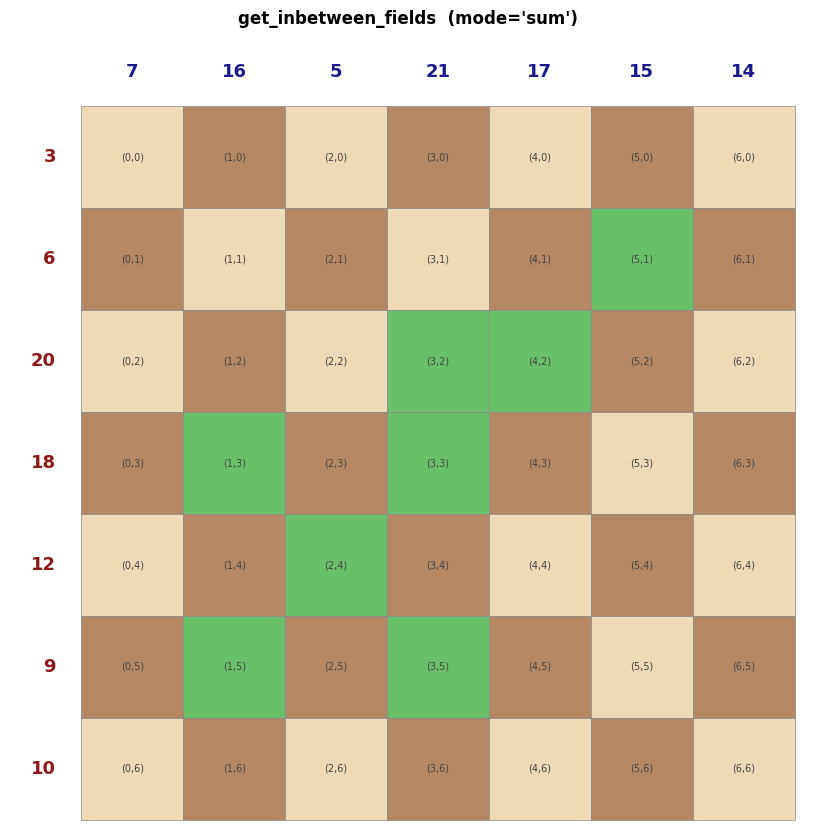

In [26]:
# ── inbetween (label sum) ─────────────────────────────────────────────────────
ib_sum = get_inbetween_fields(BOARD_SIZE, col_labels, row_labels, mode='sum')
print(f"inbetween (sum)  — {len(ib_sum)} fields: {sorted(ib_sum)}")
visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=ib_sum,
                title="get_inbetween_fields  (mode='sum')")

inbetween (product)  — 0 fields: []


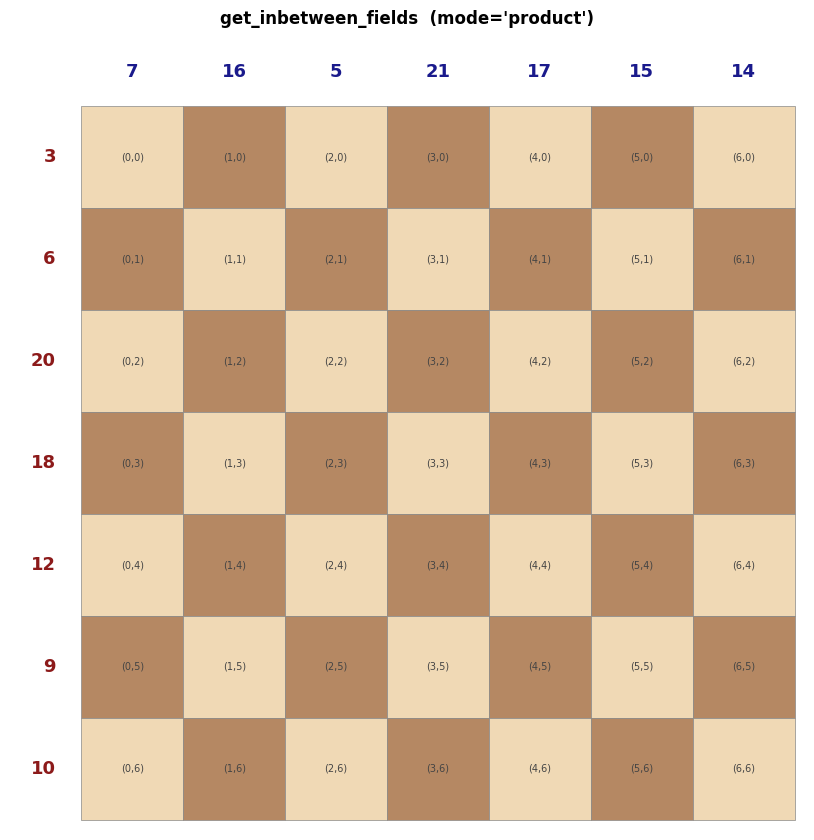

In [27]:
# ── inbetween (label product) ─────────────────────────────────────────────────
ib_prod = get_inbetween_fields(BOARD_SIZE, col_labels, row_labels, mode='product')
print(f"inbetween (product)  — {len(ib_prod)} fields: {sorted(ib_prod)}")
visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=ib_prod,
                title="get_inbetween_fields  (mode='product')")

center  — 1 field(s): [(5, 6)]


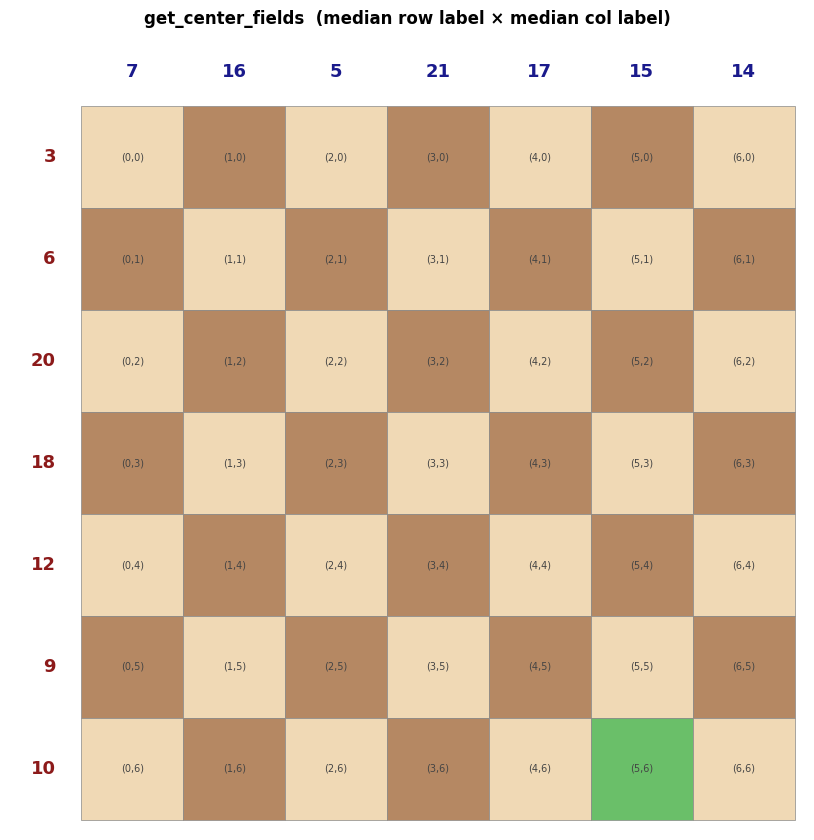

In [28]:
# ── center ────────────────────────────────────────────────────────────────────
cf = get_center_fields(BOARD_SIZE, col_labels, row_labels)
print(f"center  — {len(cf)} field(s): {sorted(cf)}")
visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=cf,
                title="get_center_fields  (median row label × median col label)")

label_plus_coord  — 7 field(s): [(0, 1), (1, 4), (1, 6), (3, 3), (5, 2), (6, 2), (6, 5)]


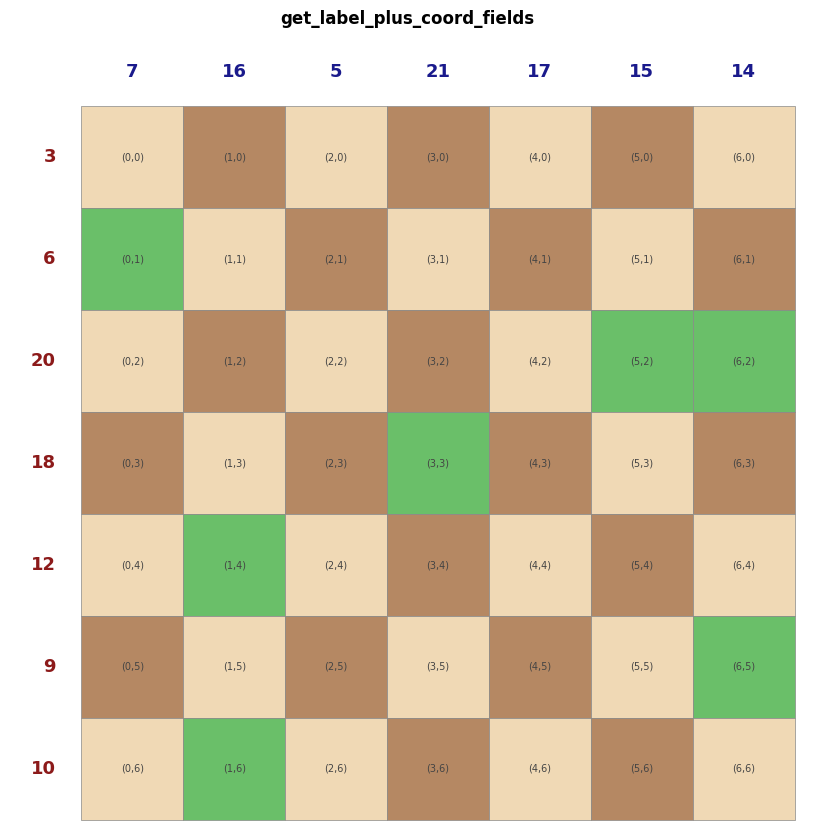

In [29]:
# ── label + coord ─────────────────────────────────────────────────────────────
lpc = get_label_plus_coord_fields(BOARD_SIZE, col_labels, row_labels)
print(f"label_plus_coord  — {len(lpc)} field(s): {sorted(lpc)}")
visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=lpc,
                title="get_label_plus_coord_fields")

sum_min (min)  — 6 field(s): [(0, 0), (0, 5), (2, 0), (2, 5), (6, 0), (6, 5)]


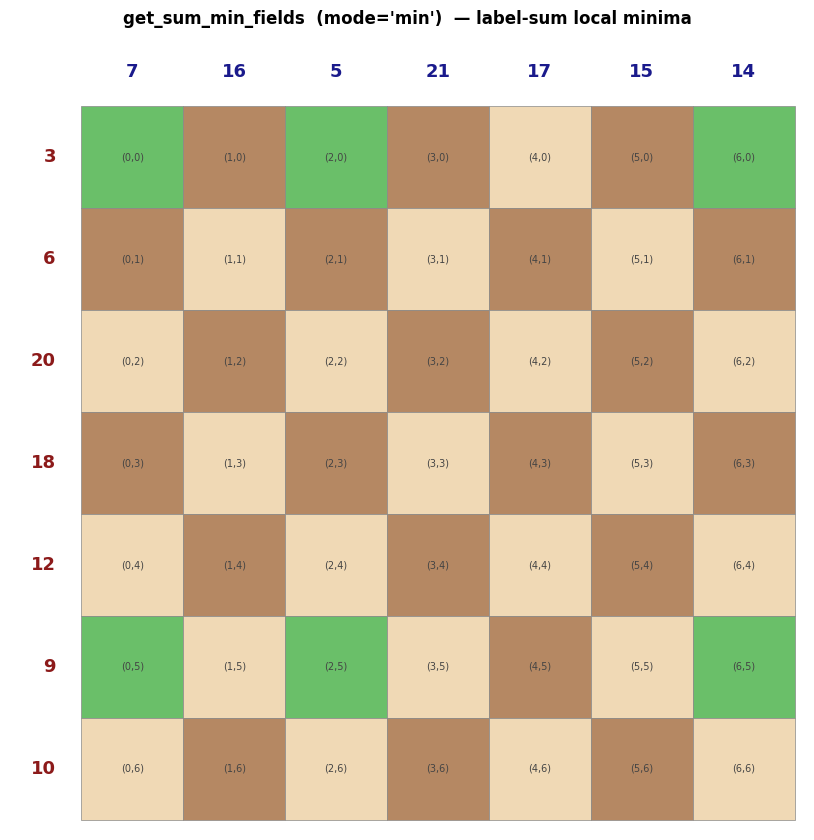

In [30]:
# ── label-sum local minima ────────────────────────────────────────────────────
sm_min = get_sum_min_fields(BOARD_SIZE, col_labels, row_labels, mode='min')
print(f"sum_min (min)  — {len(sm_min)} field(s): {sorted(sm_min)}")
visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=sm_min,
                title="get_sum_min_fields  (mode='min')  — label-sum local minima")

sum_min (max)  — 4 field(s): [(1, 2), (1, 6), (3, 2), (3, 6)]


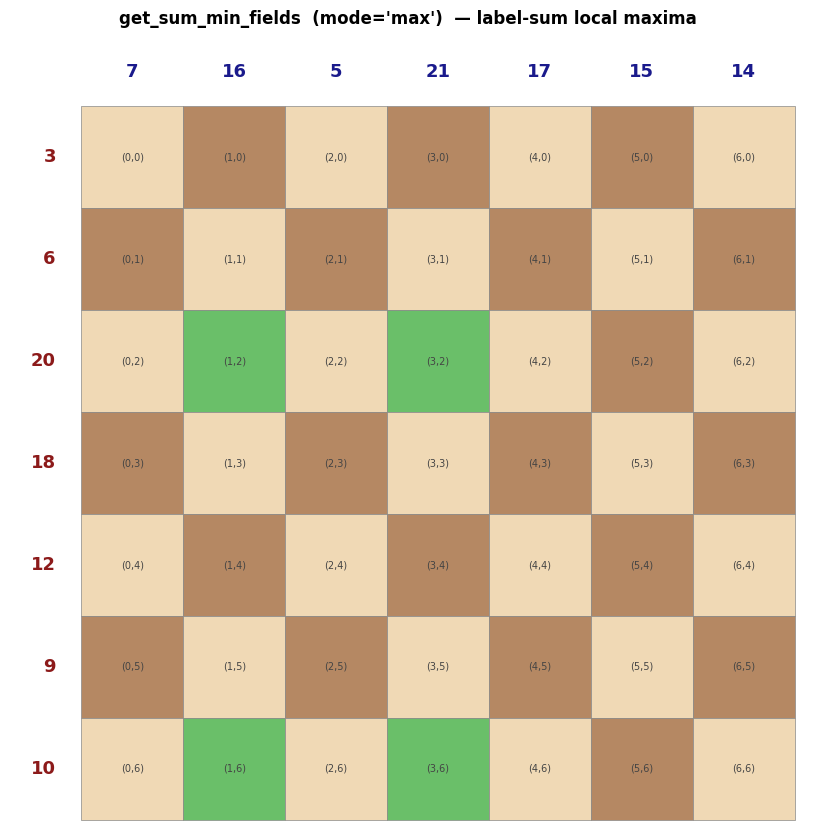

In [31]:
# ── label-sum local maxima ────────────────────────────────────────────────────
sm_max = get_sum_min_fields(BOARD_SIZE, col_labels, row_labels, mode='max')
print(f"sum_min (max)  — {len(sm_max)} field(s): {sorted(sm_max)}")
visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=sm_max,
                title="get_sum_min_fields  (mode='max')  — label-sum local maxima")